<a href="https://colab.research.google.com/github/behnke55/2245_labwork_in_progress/blob/main/ES2245_lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory 9: Statistical and Spectral Analysis in Geophysics
**Course:** EARTHSC 2245: Introductory Data Analysis for Earth and Environmental Sciences

**Topics** Non-Parametric Tests, Time-Domain, and Frequency-Domain Analysis


**Objective:** Apply concepts from Lectures 21 and 22 to analyze geological and seismic data.
1. **Lecture 21 Focus:** Non-parametric statistics (Friedman, Spearman) and Time-domain analysis (Moving averages, Aliasing, Correlation).
2. **Lecture 22 Focus:** Frequency-domain analysis (FFT, PSD), Spectrograms, and digital filtering.

In [1]:
#Run this line once, you will have to reload lab, then you can comment this out
!pip install obspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 53.3 MB/s eta 0:00:00


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
import obspy
from obspy.clients.fdsn import Client

# Set plot style for the notebook
plt.rcParams['figure.figsize'] = [10, 6]
%matplotlib inline

## Task 1: Non-Parametric Comparisons (Friedman Test)
**Concept:** When data doesn't follow a normal distribution, we use the Friedman test to compare 3+ related samples.
**Scenario:** You have 5 rock samples. You measure their permeability ($mD$) under three different confining pressures (10MPa, 20MPa, 30MPa). Does pressure significantly change permeability?

In [3]:
perm_data = np.array([
    [15.2, 14.8, 13.9], # Sample 1
    [10.1, 9.5, 8.2],   # Sample 2
    [25.4, 24.1, 23.0], # Sample 3
    [5.5, 5.0, 4.1],    # Sample 4
    [18.9, 17.5, 16.2]  # Sample 5
])

### STUDENT CODE HERE ###
# Hint: Use stats.friedmanchisquare()
# Pass the three columns as arguments: perm_data[:, 0], perm_data[:, 1], and perm_data[:, 2]

# result = ...
result = stats.friedmanchisquare(perm_data[:, 0], perm_data[:, 1], perm_data[:, 2])
print(f"Friedman Test Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")
if result.pvalue < 0.05:
    print("Result: Pressure significantly changes the permeability.")
else:
    print("Result: Pressure does not significantly change the permeability between pressure levels.")

Friedman Test Statistic: 10.0000
P-value: 0.0067
Result: Pressure significantly changes the permeability.


##Task 2: Spearman Rank Correlation

**Concept:** Use Spearman's $\rho$ to find monotonic relationships between variables that are not necessarily linear (e.g., Mineral concentration vs. Depth).

In [4]:
# Depth (m) and Gold Concentration (ppm)
depth = np.array([100, 200, 300, 400, 500, 600, 700, 800])
gold_ppm = np.array([0.2, 0.5, 1.1, 2.4, 5.1, 10.2, 11.5, 12.1])

### STUDENT CODE HERE ###
# Hint: Use stats.spearmanr(x, y) to calculate the correlation coefficient and p-value.

rho, p_val = stats.spearmanr(depth, gold_ppm)

print(f"Spearman correlation: {rho:.4f}")
print(f"P-value: {p_val:.4f}")

Spearman correlation: 1.0000
P-value: 0.0000


##Task 3: The Nyquist Frequency and Aliasing

**Concept:** Lecture 21 discusses Aliasing. If your sampling frequency ($f_s$) is less than twice the highest frequency in your signal ($2 \times f_{max}$), you get artifacts.

**Goal:** Create a 10 Hz sine wave. Sample it correctly (e.g., 50 Hz) and incorrectly (e.g., 12 Hz) to see aliasing.

The Nyquist frequency is 6.0 Hz. Since our signal is 10 Hz, we expect aliasing.


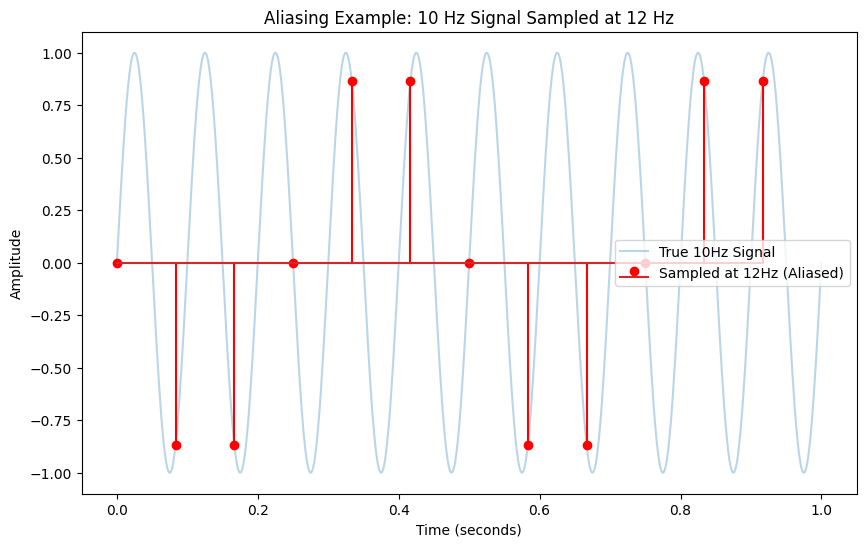

In [5]:
t_fine = np.linspace(0, 1, 1000)
f_signal = 10 # 10 Hz signal
y_true = np.sin(2 * np.pi * f_signal * t_fine)

# Low sampling rate (Aliasing!)
fs_low = 12
t_low = np.arange(0, 1, 1/fs_low)
y_low = np.sin(2 * np.pi * f_signal * t_low)

plt.plot(t_fine, y_true, label='True 10Hz Signal', alpha=0.3)
plt.stem(t_low, y_low, 'r', label='Sampled at 12Hz (Aliased)')

### STUDENT CODE HERE ###
# 1. Calculate the Nyquist frequency for a 12Hz sampling rate.
# 2. Add a title and labels to the plot.

nyquist = fs_low / 2
plt.title("Aliasing Example: 10 Hz Signal Sampled at 12 Hz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
print(f"The Nyquist frequency is {nyquist} Hz. Since our signal is {f_signal} Hz, we expect aliasing.")

plt.legend()
plt.show()

##Task 4: Cross-Correlation (Travel Time)

**Concept:** Cross-correlation identifies the time lag between two signals. In seismology, we use this to find the travel time of a wave between two sensors.

Detected Time Delay: 0.390 seconds


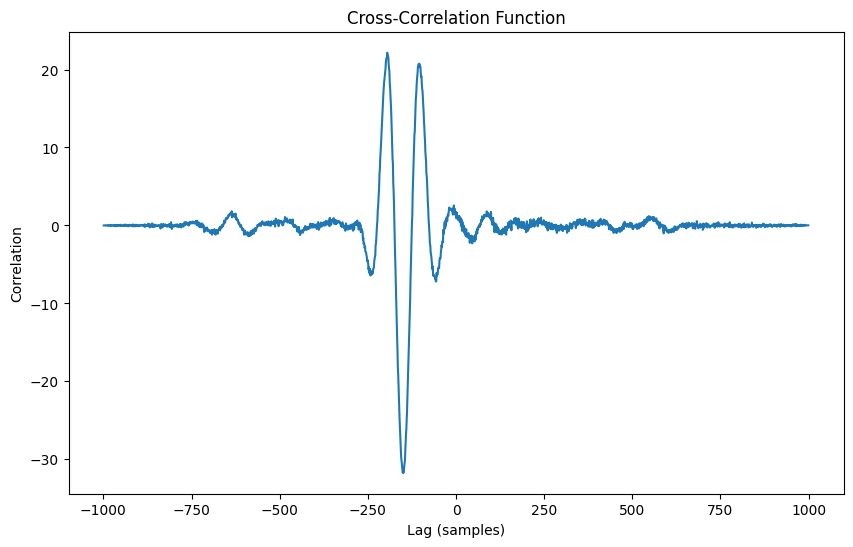

In [6]:
# Create a synthetic seismic pulse
t = np.linspace(0, 2, 1000)
def pulse(time, center):
    return np.exp(-(time-center)**2 / 0.01) * np.sin(2 * np.pi * 5 * time)

sensor1 = pulse(t, 0.5) + np.random.normal(0, 0.1, 1000)
sensor2 = pulse(t, 0.8) + np.random.normal(0, 0.1, 1000) # Delayed by 0.3s

### STUDENT CODE HERE ###
# Hint: Use np.correlate with mode='full'.
# The index of the maximum correlation value tells you the lag.

correlation = np.correlate(sensor1, sensor2, mode='full')
lags = np.arange(-len(sensor1) + 1, len(sensor1))
best_lag_idx = np.argmax(correlation)
time_delay = lags[best_lag_idx] * (t[1] - t[0])

print(f"Detected Time Delay: {abs(time_delay):.3f} seconds")

plt.plot(lags, correlation)
plt.title("Cross-Correlation Function")
plt.xlabel("Lag (samples)")
plt.ylabel("Correlation")
plt.show()

## Task 5: Frequency Domain - Power Spectral Density (PSD)
**Concept:** Lecture 22 explains that a Power Spectrum pulls apart "composite" signals to reveal hidden periodicities (like the 24-hour cycle vs. 365-day cycle). In seismology, we use PSDs to distinguish between seismic events and background "ambient noise."

/usr/local/lib/python3.12/dist-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)


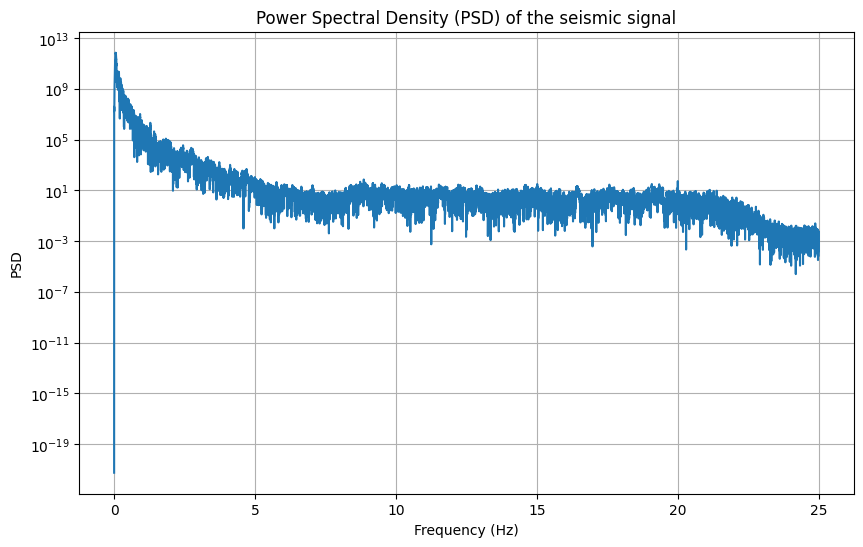

In [7]:
# Fetching data for a recent event using ObsPy
client = Client("IRIS")
starttime = obspy.UTCDateTime("2023-07-16T06:48:00") # M7.2 Alaska Event
st = client.get_waveforms("AK", "COLD", "", "BHZ", starttime, starttime + 600)
tr = st[0]

# Pre-processing: Always detrend and taper before spectral analysis
tr.detrend('linear')
tr.taper(0.05)

### STUDENT CODE HERE ###
# 1. Use scipy.signal.periodogram to calculate the PSD.
# 2. Plot the result on a log-log or semilogy scale.
# Hint: freq, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)

# freqs, psd = ...
# plt.semilogy(...)
freqs, psd = signal.periodogram(tr.data, fs=tr.stats.sampling_rate)
plt.figure(figsize=(10, 6))
plt.semilogy(freqs, psd)
plt.title("Power Spectral Density (PSD) of the seismic signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

## Task 6: Time-Frequency Analysis - Spectrograms
**Concept:** A Power Spectrum (PSD) tells you *what* frequencies exist in the data, but a **Spectrogram** tells you *when* those frequencies occur. This is critical for identifying the arrival of different seismic phases (P-waves vs. S-waves).

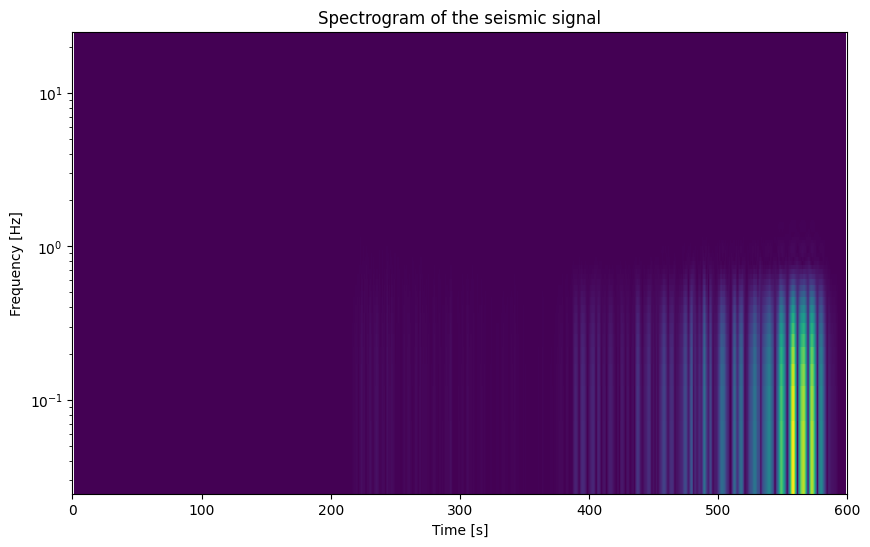

In [8]:
### STUDENT CODE HERE ###
# Hint: ObsPy Trace objects have a built-in .spectrogram() method.
# Apply it to the trace 'tr' we downloaded in the previous cell.
# Use 'log=True' in the spectrogram method to see the earthquake energy clearly.

# tr.spectrogram(...)
tr.spectrogram(log=True, title="Spectrogram of the seismic signal")

##Task 7: Wavelet Transform

**Concept** A wavelet transform is roughly equivalent to a spectrogram, except analysis is performed in the time domain.

**Task:** Write all of the code to perform a wavelet transform on the trace from Tasks 5 and 6 and plot them. Perform two different wavelet transforms for different wavelet parameters (minimum and maximum frequencies

The resource found here shows how to do this in obspy: https://docs.obspy.org/archive/stable/tutorial/code_snippets/continuous_wavelet_transform.html

In [13]:
### STUDENT CODE HERE ###

from obspy.signal.wavelets import cwt
import matplotlib.pyplot as plt
import numpy as np

#Trace Data
data = tr.data
dt = tr.stats.delta
npts = tr.stats.npts
time = np.arange(0, npts) * dt
#--------------------------------
#Wavelet Transform 1
#Lower freq. range
f_min1 = 0.1
f_max1 = 5
scalogram1 = cwt(data, dt, 8, f_min1, f_max1)
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(scalogram1), extent=[time[0],time[-1], f_min1, f_max1], aspect='auto', cmap='jet', origin='lower')
plt.colorbar(label='Amplitude')
plt.title("Wavelet Transform: 0.1 to 5 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()
#--------------------------------
#Wavelet Transform 2
#Higher freq. range
f_min2 =1
f_max2 = 20
scalogram2 = cwt(data, dt, 8, f_min2, f_max2)
plt.figure(figsize=(10, 6))
plt.imshow(np.abs(scalogram2), extent=[time[0],time[-1], f_min2, f_max2], aspect='auto', origin='lower')
plt.colorbar(label='Amplitude')
plt.title("Wavelet Transform: 1 to 20 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.show()

ModuleNotFoundError: No module named 'obspy.signal.wavelets'

## Lab Questions for Submission

### Question 1: Power Spectra
Based on your PSD plot in Task 5, you likely see a high-energy peak at very low frequencies (below 1 Hz) and a drop-off at higher frequencies. In the context of Lecture 22, why is the frequency domain more useful than the time domain for identifying a "dominant period" in noisy data?


The frequency domain is more useful because it makes it easier to see what frequencies are actually strongest within the data. In the time-domain graph, the seismic signal can look messy because the earthquake's motion and background noise are all mixed together. The PSD plot separates the signal by frequency, this is so we can see where most of the energy actually is. If most of the energy is below 1 Hz, then the dominant period is much easier to identify. Frequency domain helps to pull out patterns that are hard to see just by looking at the raw seismogram.
### Question 2: Spectrograms
Compare the static PSD plot from Task 5 to the Spectrogram in Task 6.
* Which plot better illustrates a signal whose frequency content changes over time?
* If you see a vertical "blast" of energy across many frequencies at a specific time, what does that represent in the seismogram?

The spectrogram is better for showing a signal whose frequency content changes over time. The PSD plt shows what frequencies are present overall, but it does not really show when those frequencies happen. The spectrogram is more useful because it shows both the time and frequency at the same time.
If there is a vertical "blast" of energy across many frequencies, that likely means a sudden seismic arrival happened at that point in time. In the seismogram, this could represent the arrival of a wave phase, like a p wave or s wave, or another sudden event that released the energy across a wide band of frequencies.
### Question 3: Wavelet Transforms
Lecture 22 mentions **Wavelet Transforms** as another technique for frequency analysis.
* **Hint:** Unlike the Fourier Transform (which uses infinite sines and cosines), Wavelets use short-duration "pulses."
* **Question:** Why might a Wavelet Transform be superior to a standard Fourier Transform for a seismic signal that contains sudden, short-lived "jolts" (like a rockfall or an explosion)?

A wavelet transorm can be better than a regular Fourier transform for sudden seismic jolts because wavelets are shorter and more focused during a point in time. Fourtier transform is good for showing the overall frequencies in a signal, but it is not as good at showing exactly when a quick event happened. Since things like rockfalls or explosions happen suddenly, wavelets can capture those short bursts better. This makes wavelets useful because they show both the frquency of the signal and when that energy occured.

### Question 4: Filtering
If you were looking for **Earth Tides** (very slow deformations with a period of ~12 hours), would you use a High-Pass or a Low-Pass filter to remove the "noise" of earthquakes and traffic? Why?

I would use a low pass filter for the tides on Earth. Earth tides happen slowly, with periods of around 12 hours between high and low, so they are considered low frequency signals due to the long time between them. Noise from earthquakes, traffic, or other types of vibrations usually have higher frquencies. A low pass filter would keep the slow Earth tide signal while removing the higher frequency noises. A high pass filter would not be a good choice because it would instead remove the slow signal entirely.